In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load datasets

train_df = pd.read_csv("/content/customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")

print("Training Shape :", train_df.shape)
print("Testing Shape :", test_df.shape)

train_df.head()

Training Shape : (440833, 12)
Testing Shape : (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [6]:
print("Dataset Information")
train_df.info()

print("\nColumns")
print(train_df.columns)

print("\nTarget Variable Distribution")
print(train_df['Churn'].value_counts())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB

Columns
Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription

In [7]:
# Target Variable
target = "Churn"

# Numerical Features
numerical_cols = train_df.select_dtypes(include=['int64','float64']).columns.tolist()

# Remove target if numeric
if target in numerical_cols:
    numerical_cols.remove(target)

# Categorical Features
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

if target in categorical_cols:
    categorical_cols.remove(target)

print("Target Variable :", target)

print("\nNumerical Features")
print(numerical_cols)

print("\nCategorical Features")
print(categorical_cols)

Target Variable : Churn

Numerical Features
['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

Categorical Features
['Gender', 'Subscription Type', 'Contract Length']


In [8]:
print(train_df.isnull().sum())

# Fill numerical missing values
for col in numerical_cols:
    train_df[col].fillna(train_df[col].median(), inplace=True)
    test_df[col].fillna(train_df[col].median(), inplace=True)

# Fill categorical missing values
for col in categorical_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)
    test_df[col].fillna(train_df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning")
print(train_df.isnull().sum().sum())

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64
Missing Values After Cleaning
1


In [9]:
label_encoders = {}

for col in categorical_cols + [target]:

    le = LabelEncoder()

    train_df[col] = le.fit_transform(train_df[col])

    test_df[col] = le.transform(test_df[col])

    label_encoders[col] = le

print("Encoding Completed")

Encoding Completed


In [10]:
scaler = StandardScaler()

train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])

test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

print("Feature Scaling Completed")

Feature Scaling Completed


In [11]:
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

print(X_train.shape)
print(X_test.shape)

(440833, 11)
(64374, 11)


In [12]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Completed")

Logistic Regression Completed


In [13]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Completed")

Decision Tree Completed


In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Completed")

Random Forest Completed


In [15]:
def evaluate_model(name, y_true, y_pred):

    print("="*60)
    print(name)
    print("="*60)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return [name, accuracy, precision, recall, f1]

Logistic Regression
Accuracy : 0.47368502811694163
Precision: 0.47368502811694163
Recall   : 1.0
F1 Score : 0.6428578957909494

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     33881
           1       0.47      1.00      0.64     30493

    accuracy                           0.47     64374
   macro avg       0.24      0.50      0.32     64374
weighted avg       0.22      0.47      0.30     64374



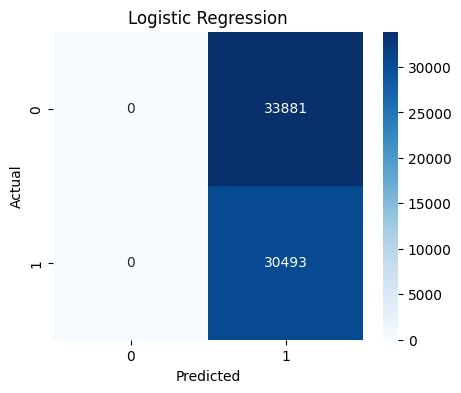

In [16]:
lr_result = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

Decision Tree
Accuracy : 0.5032155839314009
Precision: 0.48808627237329144
Recall   : 0.9989177844095366
F1 Score : 0.6557588805166846

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.74      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374



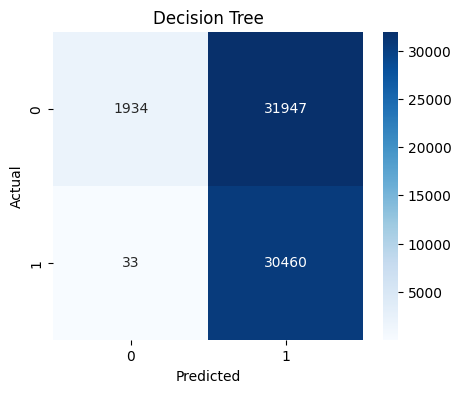

In [17]:
dt_result = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

Random Forest
Accuracy : 0.4948737067760276
Precision: 0.48393548796749
Recall   : 0.9997704391171744
F1 Score : 0.6521836793633475

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.04      0.08     33881
           1       0.48      1.00      0.65     30493

    accuracy                           0.49     64374
   macro avg       0.74      0.52      0.36     64374
weighted avg       0.75      0.49      0.35     64374



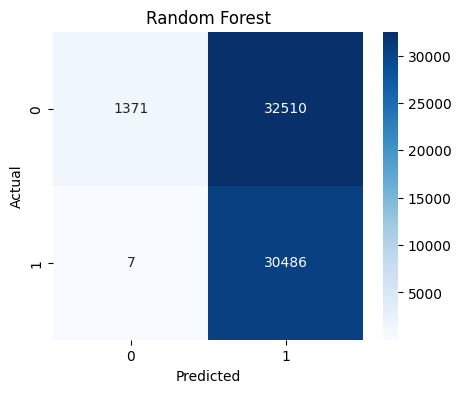

In [24]:
rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

In [25]:
results = pd.DataFrame(
    [lr_result, dt_result, rf_result],
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.503216,0.488086,0.998918,0.655759
1,Random Forest,0.494874,0.483935,0.999770,0.652184
2,Logistic Regression,0.473685,0.473685,1.000000,0.642858


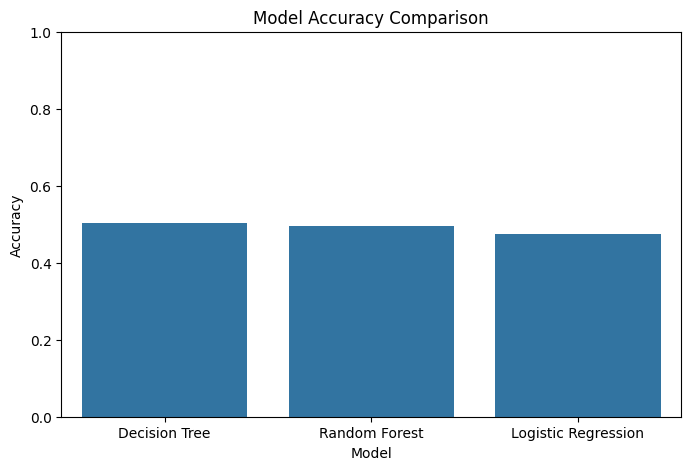

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

In [27]:
best_model = results.iloc[0]

print("Best Performing Model")
print("------------------------")
print(f"Model      : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1 Score   : {best_model['F1 Score']:.4f}")

Best Performing Model
------------------------
Model      : Decision Tree
Accuracy   : 0.5032
Precision  : 0.4881
Recall     : 0.9989
F1 Score   : 0.6558
